## 0. Fundaments

### 0.1 Crucial imports

In [1556]:
import webdataset as wds
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision import models
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'
torch.cuda.is_available()


True

### 0.2 Seeting seed

In [1557]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(6767)

# 1. Data Preparation

### 1.1 Read data to dataframme 
- Reading data to pandas dataframe 
- Making Dataframe searchable by 'name.png' by changing ID from integers to name of the image

In [1558]:
df = pd.read_csv("Data_Entry_2017.csv")
df = df.set_index('Image Index')
print(df.head(3))


                          Finding Labels  Follow-up #  Patient ID Patient Age  \
Image Index                                                                     
00000001_000.png            Cardiomegaly            0           1        058Y   
00000001_001.png  Cardiomegaly|Emphysema            1           1        058Y   
00000001_002.png   Cardiomegaly|Effusion            2           1        058Y   

                 Patient Gender View Position  OriginalImage[Width  Height]  \
Image Index                                                                   
00000001_000.png              M            PA                 2682     2749   
00000001_001.png              M            PA                 2894     2729   
00000001_002.png              M            PA                 2500     2048   

                  OriginalImagePixelSpacing[x     y]  Unnamed: 11  
Image Index                                                        
00000001_000.png                        0.143  0.143          

### 1.2 Encode labels to vector
* Introduce label encoding (not one-hot because of multilabel instances)
* Introduce function returning labels with probability greater than threshold from list of probabilities

In [1559]:
all_labels = [
    "No Finding", "Atelectasis", "Consolidation", "Infiltration", 
    "Pneumothorax", "Edema", "Emphysema", "Fibrosis", "Effusion", 
    "Pneumonia", "Pleural_Thickening", "Cardiomegaly", "Nodule", "Mass", "Hernia"
]
label_to_idx = {label:i for i, label in enumerate(all_labels)}


def encode_label(label):
    vector_labels = torch.zeros(len(all_labels), dtype=torch.float32)
    
    if not isinstance(label, str): #handling NaN or empty
        return vector_labels
    
    labels = label.split("|")
    for l in labels:
        if l not in label_to_idx: #handling inproper names of diseases
            continue
        vector_labels[label_to_idx[l]] = 1.0

    return vector_labels


def vector_idx_to_labels(vector_idx, threshold):
    return [label for label, val in zip(all_labels, vector_idx) if val>=threshold]

### 1.3 Shuffling DataFrame and splitting into Training and Validation

In [1560]:
shuffled_df = df.sample(frac=1)
print(shuffled_df.head(1))


population_size = len(df)
train_split = int(0.8*population_size)

train_df = shuffled_df[:train_split]
val_df = shuffled_df[train_split:]

len(shuffled_df), len(train_df), len(val_df)

                 Finding Labels  Follow-up #  Patient ID Patient Age  \
Image Index                                                            
00012291_016.png     No Finding           16       12291        056Y   

                 Patient Gender View Position  OriginalImage[Width  Height]  \
Image Index                                                                   
00012291_016.png              M            PA                 3056     2544   

                  OriginalImagePixelSpacing[x     y]  Unnamed: 11  
Image Index                                                        
00012291_016.png                        0.139  0.139          NaN  


(112120, 89696, 22424)

### 1.4 Processing images to correct format 

From each image extracting tensors of pixels and resizing to correct format (here for AlexNet but must be corrected)

In [1561]:
process_image = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.255])
])

def process(sample):

    image_tensor = sample['png']
    full_key = sample["__key__"]
    clean_key = full_key.replace("images/", "") + ".png"
    vector_label = encode_label(df.at[clean_key, 'Finding Labels'])

    image_tensor = process_image(image_tensor) #this can be used when we want to normalize pictures for given model

    return image_tensor, vector_label



### 1.5 Defining Datasets
* url - where the data is
* select - selecting training or validation
* shuffle - randomizing once again
* map - processing image to correct format using previous function

In [1562]:
url = "images/images_{001..012}.tar.gz"
train_dataset = (
    wds.WebDataset(url, shardshuffle=6767)
    .select(lambda x: (x["__key__"].replace("images/", "") + ".png") in train_df.index)
    .shuffle(1000)
    .decode("torchrgb")
    .map(process)
)
val_dataset = (
    wds.WebDataset(url, shardshuffle=False) 
    .select(lambda x: (x["__key__"].replace("images/", "") + ".png") in val_df.index)
    .decode("torchrgb")
    .map(process)
)


for (image, vector_label) in train_dataset:
    print(f" image shape={image.shape}, labels={vector_idx_to_labels(vector_label, 1)}")
    break


 image shape=torch.Size([3, 224, 224]), labels=['Infiltration']


## 2. Example Usage

### 2.1 Displaying three samples

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0180318..2.3585434].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0667887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.7282062].


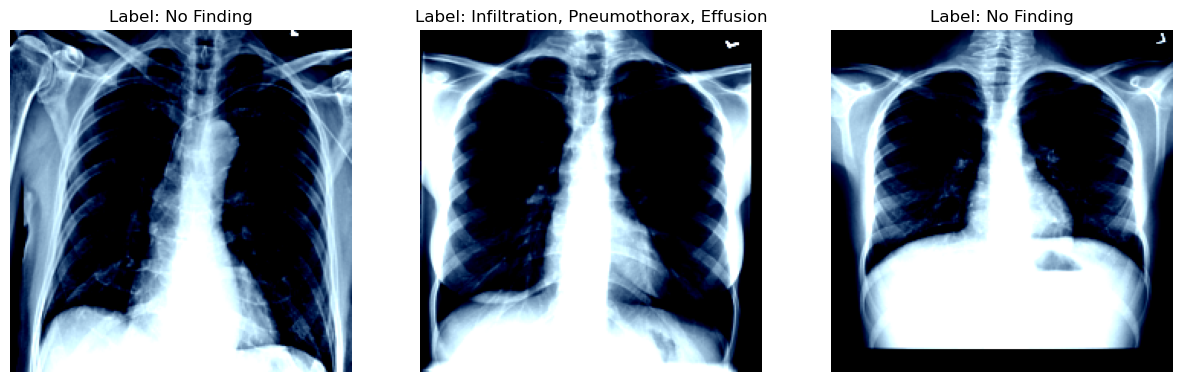

In [1563]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sample_iter = iter(train_dataset)

for i in range(3):
    image_tensor, label = next(sample_iter)
    img = image_tensor.permute(1, 2, 0).numpy()

    axes[i].imshow(img)
    label_text = ", ".join(vector_idx_to_labels(label, 1))
    axes[i].set_title(f"Label: {label_text}")
    axes[i].axis('off')

plt.show()

### 2.2 Preprocessing one image
Adding dimension to create artificial batch and moving the batch to correct device

In [1564]:
stream = iter(train_dataset)
sample_image,sample_label = next(stream)

input_batch = sample_image.unsqueeze(0)

input_batch = input_batch.to(device)

print(f"Shape of inputting batch: {input_batch.shape}")
print(f"True Label of sample: {vector_idx_to_labels(sample_label,1)}")
print(f"Device on which input is: {input_batch.device}")

Shape of inputting batch: torch.Size([1, 3, 224, 224])
True Label of sample: ['No Finding']
Device on which input is: cuda:0


### 2.3 Preprocessing example model
Loading example model with frozen parameters, shrinking outputs to 6 and moving to the device 

Normalizing output with softmax to get probabilities

In [1565]:
model = models.alexnet(weights='IMAGENET1K_V1')
for param in model.features.parameters():
    param.requires_grad = False
num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, 12) 
model = model.to(device)

output = model(input_batch)
output = torch.nn.functional.softmax(output, dim = 1)
output

tensor([[0.1142, 0.0550, 0.2059, 0.0138, 0.0723, 0.0879, 0.0509, 0.0396, 0.0849,
         0.1511, 0.0473, 0.0771]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

### 2.4 Printing chosen classes

In [1566]:
threshold = 0.12
probabilities = output[0]

picked_class = vector_idx_to_labels(probabilities, threshold=threshold)

print(f"--- Analysis Report (Threshold: {threshold*100}%) ---")
if len(picked_class) == 0:
    print("No diseases detected above threshold.")
else:
    print(picked_class)

--- Analysis Report (Threshold: 12.0%) ---
['Consolidation', 'Pneumonia']


# 3. Creating Model